# Team
- Stefanos Panteli UC1065916<br>
spante01@ucy.ac.cy

- Evangelia Krigkou UC1067400<br>
ekrigk01@ucy.ac.cy

- Rafael Chrysanthou UC1064747<br>
rchrys03@ucy.ac.cy

- Kyprianos Erakleous UC1058854<br>
kerakl02@ucy.ac.cy


GitHub: [https://github.com/stefanosPanteli/EPL445](https://github.com/stefanosPanteli/EPL445)

# Installs

In [ ]:
#!pip install opencv-python matplotlib numpy

# Imports

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from pathlib import Path

# Contants & Globals

In [ ]:
UNDERLINE = '\033[4m'
BOLD = '\033[1m'
CYAN = '\033[36m'
WHITE = '\033[37m'
RESET = '\033[0m'
def nicely_print(title: str, content: str) -> None:
    '''
    `nicely_print` prints a title and content in a nice format.

    `Args:`
        title (str): The title of the section. Will be Underlined, Bold, Cyan.
        content (str): The content of the section. Will be Bold, White.
    '''
    print(f'{UNDERLINE}{BOLD}{CYAN}{title}{RESET}', end=' ')
    print(f'{BOLD}{WHITE}{content}{RESET}\n')

label_to_int = {
    'not_initialized': 0,
    'incision': 1,
    'viscoelasticum': 2,
    'rhexis': 3,
    'hydrodissektion': 4,
    'phako': 5,
    'irrigation-aspiration': 6,
    'kapselpolishing': 7,
    'linsenimplantation': 8,
    'visco-absaugung': 9,
    'tonisieren': 10,
    'antibiotikum': 11
}
phase_order = [label.lower() for label in label_to_int.keys()]

phase_to_color = {
    label: plt.get_cmap("tab20")(i % plt.get_cmap("tab20").N)
    for i, label in enumerate(phase_order)
}

# Getting to Know the Dataset

## Init Data

In [ ]:
def load_case_annotations(csv_path: Path) -> dict[int, int | str]:
    '''
    `load_case_annotations` loads the annotations for a single case.
        Reads the CSV file and returns a dictionary {frame_number: label}.

    `Args:`
        csv_path (Path): The path to the CSV file.

    `Returns:`
        dict[int, int | str]: A dictionary of annotations.
    '''
    df = pd.read_csv(csv_path, names= ['frame_no', 'label'])
    return {
        int(frame): label
        for frame, label in zip(df['frame_no'], df['label'])
    }


def build_cases_dict(root_dir: str) -> dict[str, dict[int, dict]]:
    '''
    `build_cases_dict` builds a dictionary for every case in the dataset.

    `Args:`
        root_dir (str): The root directory of the dataset.

    `Returns:`
        dict[str, dict[int, dict]]: A dictionary of cases.
        * Format: { 'train/val': { case_id: { 'video_path': str, 'annotations': dict }
    '''
    root = Path(root_dir)

    cases = {
        'train': {},
        'val': {}
    }

    split_map = {
        'training': 'train',
        'validation': 'val'
    }

    for folder_name, split_name in split_map.items():
        split_dir = root / folder_name

        if not split_dir.exists():
            print(f'Warning: folder not found -> {split_dir}')
            continue

        for video_path in sorted(split_dir.glob('case_*.mp4')):
            case_name = video_path.stem # Removes .mp4
            csv_path = split_dir / f'{case_name}.csv'

            if not csv_path.exists():
                print(f'Warning: missing CSV for {video_path.name}')
                continue

            try:
                case_id = int(case_name.split("_")[1])
            except (IndexError, ValueError):
                print(f'Warning: could not parse case id from {video_path.name}')
                continue

            annotations = load_case_annotations(csv_path)

            cases[split_name][case_id] = {
                'video_path': str(video_path),
                'annotations': annotations
            }

    return cases

nicely_print('Fetching', 'Video Paths & Annotations')
cases = build_cases_dict('cat-21')


for split, cases_dict in cases.items():
    print(f'Split: {split}')
    for case_id, case_info in cases_dict.items():
        last_label = ''
        print(f'  Case ID: {case_id}')
        print(f'  - Video Path: {case_info["video_path"]}')
        print(f'  - Annotations:')
        for frame, label in case_info['annotations'].items():
            if label == last_label: continue
            print(f'      {frame:>5} - {label}')
            last_label = label
        print()
    print()

Fetching Video Paths & Annotations

Split: train
  Case ID: 1
  - Video Path: cat-21/training/case_01.mp4
  - Annotations:
          0 - not_initialized
         68 - Incision
       1043 - Viscoelasticum
       1228 - Rhexis
       2118 - Hydrodissektion
       3478 - Phako
       6864 - Irrigation-Aspiration
       7727 - Kapselpolishing
       8473 - Viscoelasticum
       8683 - Linsenimplantation
       9482 - Visco-Absaugung
      14138 - Tonisieren
      14623 - Antibiotikum

  Case ID: 2
  - Video Path: cat-21/training/case_02.mp4
  - Annotations:
          0 - not_initialized
         20 - Incision
        357 - Viscoelasticum
        572 - Rhexis
       1030 - Hydrodissektion
       1432 - Phako
       3032 - Irrigation-Aspiration
       3963 - Kapselpolishing
       4330 - Viscoelasticum
       4495 - Linsenimplantation
       4853 - Visco-Absaugung
       5867 - Tonisieren
       6167 - Antibiotikum

  Case ID: 3
  - Video Path: cat-21/training/case_03.mp4
  - Annotations:
 

# Plot Statistics

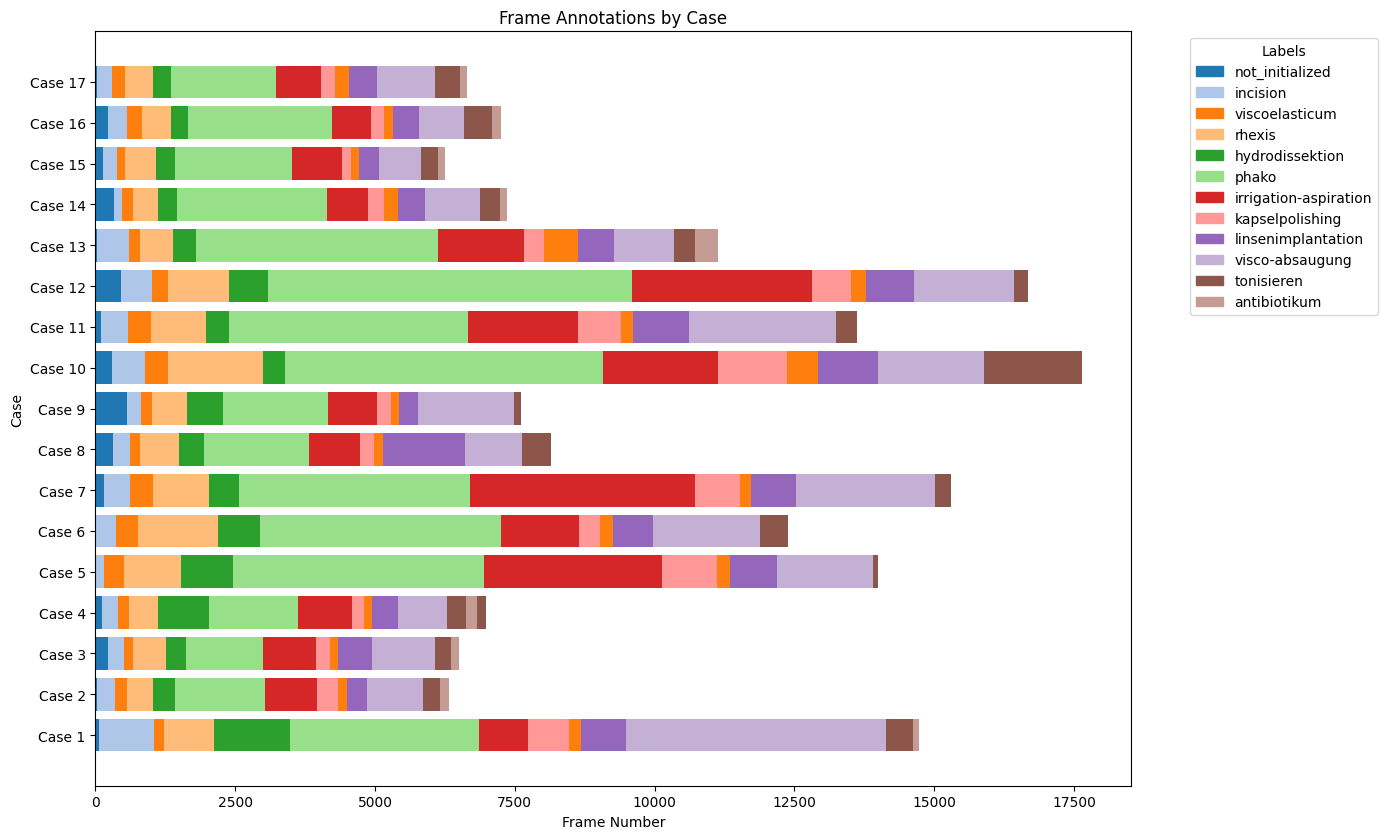

In [ ]:
def plot_frame_labels(annotations: dict[int, dict[int, str]]) -> None:
    '''
    `plot_frame_labels` plots a bar for each case, and a colour represents a label

    `Args:`
        annotations (dict[int, dict[int, str]]): A dictionary of the frame annotations.
        * Format: { case_id: { frame_number: label } }
    '''
    if not annotations:
        print('No annotations to plot.')
        return

    # Get all unique labels
    all_labels = label_to_int.keys()

    # Sort case ids for cleaner plotting
    case_ids = sorted(annotations.keys())

    plt.figure(figsize= (14, max(5, len(case_ids) * 0.5)))

    for y, case_id in enumerate(case_ids):
        frame_dict = annotations[case_id]

        if not frame_dict:
            continue

        # Sort frames
        sorted_items = sorted(frame_dict.items())   # [(frame_no, label), ...]
        frames = [item[0] for item in sorted_items]
        labels = [item[1] for item in sorted_items]

        # Merge consecutive frames with the same label into one segment
        start_frame = frames[0]
        current_label = labels[0].lower()
        prev_frame = frames[0]

        for i in range(1, len(frames)):
            frame: int = frames[i]
            label: str = labels[i].lower()

            # End current segment if label changes or frames are not consecutive
            if label != current_label or frame != prev_frame + 1:
                width = prev_frame - start_frame + 1
                plt.barh(
                    y= y, width= width, left= start_frame, height= 0.8,
                    color= phase_to_color[current_label]
                )
                start_frame = frame
                current_label = label

            prev_frame = frame

        # Plot the last segment
        width = prev_frame - start_frame + 1
        plt.barh(
            y= y, width= width, left= start_frame, height= 0.8,
            color= phase_to_color[current_label]
        )

    # Axis labels and title
    plt.yticks(range(len(case_ids)), [f'Case {case_id}' for case_id in case_ids])
    plt.xlabel('Frame Number')
    plt.ylabel('Case')
    plt.title('Frame Annotations by Case')

    # Legend
    legend_patches = [
        mpatches.Patch(color= phase_to_color[label], label= label)
        for label in all_labels
    ]
    plt.legend(handles= legend_patches, title= 'Labels', bbox_to_anchor= (1.05, 1), loc= 'upper left')

    plt.tight_layout()
    plt.show()

annotations_only = {
    case_id: case_info['annotations']
    for case_id, case_info in cases['train'].items()
}
plot_frame_labels(annotations_only)

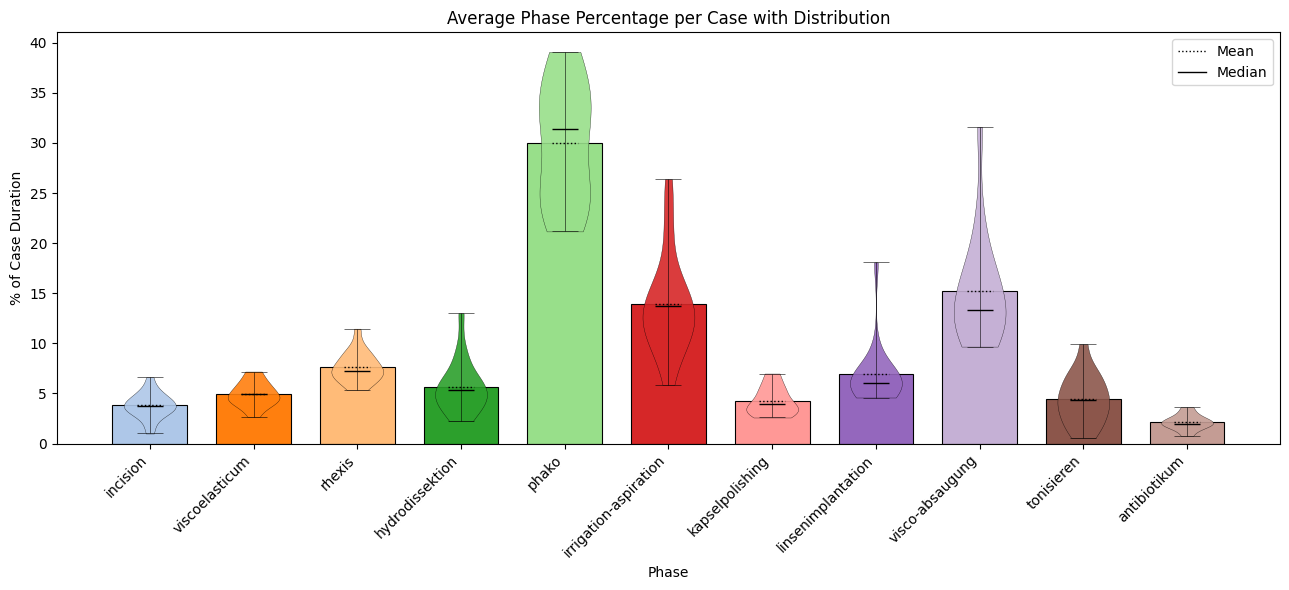

In [ ]:
def plot_phase_percentage_summary_and_distribution(annotations: dict[int, dict[int, str]]) -> pd.DataFrame:
    '''
    `plot_frame_labels` plots a bar for each case, and a colour represents a label

    `Args:`
        annotations (dict[int, dict[int, str]]): A dictionary of the frame annotations.
        * Format: { case_id: { frame_number: label } }

    `Returns:`
        pd.DataFrame: A dataframe with the percentage of total case duration occupied by each phase.
        * Columns: case_id, label, percentage
    '''
    if not annotations:
        print('No annotations to plot.')
        return pd.DataFrame(columns= ['case_id', 'label', 'percentage'])

    rows = []

    for case_id, frame_dict in annotations.items():
        if not frame_dict:
            continue

        sorted_items = sorted((int(frame), str(label).lower()) for frame, label in frame_dict.items())
        frames = [frame for frame, _ in sorted_items]
        labels = [label for _, label in sorted_items]

        case_total = frames[-1] - frames[0] + 1

        label_counts = {}
        for label in labels:
            label_counts[label] = label_counts.get(label, 0) + 1

        for label, count in label_counts.items():
            if label == 'not_initialized':
                continue

            rows.append({
                'case_id': case_id,
                'label': label,
                'percentage': count / case_total * 100
            })

    percentage_df = pd.DataFrame(rows)

    if percentage_df.empty:
        print('No valid phase percentages to plot.')
        return pd.DataFrame(columns= ['case_id', 'label', 'percentage'])

    label_order = [label.lower() for label in label_to_int.keys() if label.lower() != 'not_initialized']

    plot_df = percentage_df.copy()
    plot_df['label'] = plot_df['label'].astype(str).str.lower()
    plot_df = plot_df[plot_df['label'].isin(label_order)].copy()

    summary_df = (
        plot_df
        .groupby('label', as_index= False)['percentage']
        .mean()
    )
    summary_df['label'] = pd.Categorical(summary_df['label'], categories= label_order, ordered= True)
    summary_df = summary_df.sort_values('label').reset_index(drop= True)

    grouped_data = [
        plot_df.loc[plot_df['label'] == label, 'percentage'].values
        for label in label_order
        if not plot_df.loc[plot_df['label'] == label, 'percentage'].empty
    ]
    plotted_labels = [
        label for label in label_order
        if not plot_df.loc[plot_df['label'] == label, 'percentage'].empty
    ]

    summary_plot_df = summary_df[summary_df['label'].astype(str).isin(plotted_labels)].copy()
    summary_plot_df['label'] = summary_plot_df['label'].astype(str)

    x_positions = list(range(len(plotted_labels)))

    plt.figure(figsize= (13, 6))

    plt.bar(
        x_positions,
        summary_plot_df['percentage'],
        color= [phase_to_color[label] for label in summary_plot_df['label']],
        width= 0.72,
        edgecolor= 'black',
        linewidth= 0.8
    )

    violin_parts = plt.violinplot(
        dataset= grouped_data,
        positions= x_positions,
        widths= 0.5,
        showmeans= True,
        showmedians= True
    )

    for body, label in zip(violin_parts['bodies'], plotted_labels):
        body.set_facecolor(phase_to_color[label])
        body.set_edgecolor('black')
        body.set_alpha(0.9)
        body.set_linewidth(0.25)

    if 'cmeans' in violin_parts:
        violin_parts['cmeans'].set_color('black')
        violin_parts['cmeans'].set_linestyle(':')
        violin_parts['cmeans'].set_linewidth(1.0)

    if 'cmedians' in violin_parts:
        violin_parts['cmedians'].set_color('black')
        violin_parts['cmedians'].set_linestyle('-')
        violin_parts['cmedians'].set_linewidth(1.0)

    if 'cbars' in violin_parts:
        violin_parts['cbars'].set_color('black')
        violin_parts['cbars'].set_linewidth(0.4)

    if 'cmins' in violin_parts:
        violin_parts['cmins'].set_color('black')
        violin_parts['cmins'].set_linewidth(0.4)

    if 'cmaxes' in violin_parts:
        violin_parts['cmaxes'].set_color('black')
        violin_parts['cmaxes'].set_linewidth(0.4)

    mean_handle = plt.Line2D([0], [0], color= 'black', linestyle= ':', linewidth= 1.0, label= 'Mean')
    median_handle = plt.Line2D([0], [0], color= 'black', linestyle= '-', linewidth= 1.0, label= 'Median')

    plt.legend(handles= [mean_handle, median_handle], loc= 'upper right')
    plt.xticks(ticks= x_positions, labels= plotted_labels, rotation= 45, ha= 'right')
    plt.xlabel('Phase')
    plt.ylabel('% of Case Duration')
    plt.title('Average Phase Percentage per Case with Distribution')
    plt.tight_layout()
    plt.show()

    return percentage_df


phase_percentage_df = plot_phase_percentage_summary_and_distribution(annotations= annotations_only)

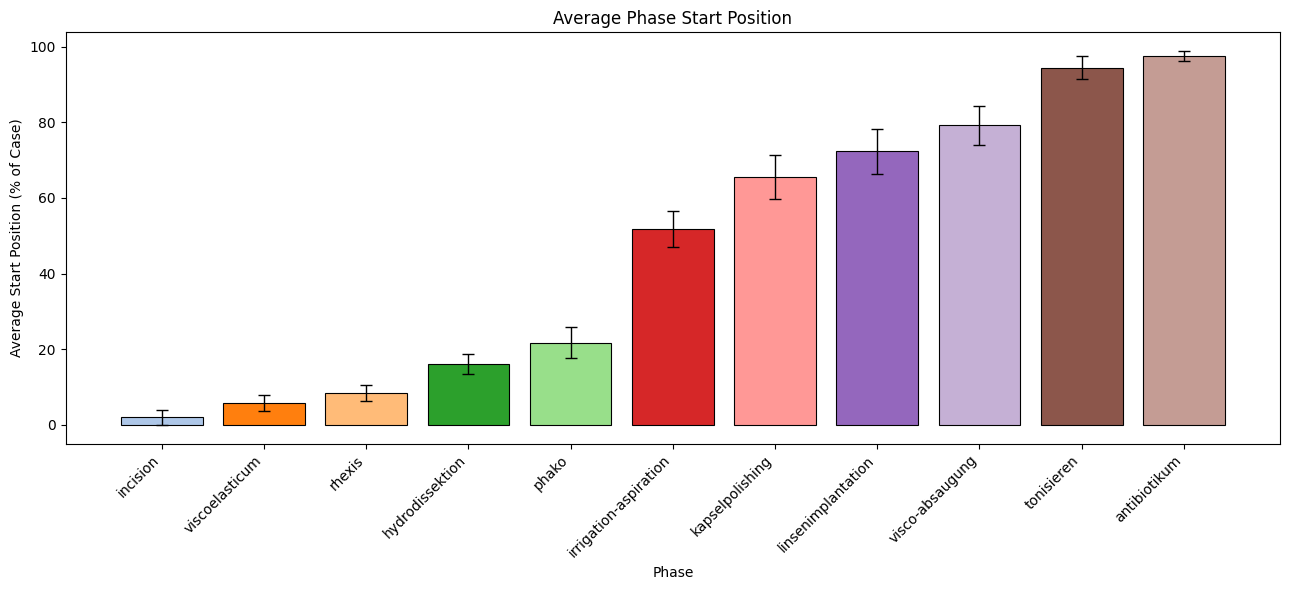

In [ ]:
def plot_phase_start_position(annotations: dict[int, dict[int, str]]) -> pd.DataFrame:
    '''
    `plot_frame_labels` plots a bar for each case, and a colour represents a label

    `Args:`
        annotations (dict[int, dict[int, str]]): A dictionary of the frame annotations.
        * Format: { case_id: { frame_number: label } }

    `Returns:`
        pd.DataFrame: A dataframe with the start percentage of each phase per case, plus summary statistics.
        * Columns: label, mean_start_percentage, median_start_percentage, std_start_percentage
    '''
    if not annotations:
        print('No annotations to plot.')
        return pd.DataFrame(columns= ['label', 'mean_start_percentage', 'median_start_percentage', 'std_start_percentage'])

    rows = []

    for case_id, frame_dict in annotations.items():
        if not frame_dict:
            continue

        sorted_items = sorted((int(frame), str(label).lower()) for frame, label in frame_dict.items())
        frames = [frame for frame, _ in sorted_items]

        case_start = frames[0]
        case_end = frames[-1]
        case_total = case_end - case_start + 1

        seen_labels = set()

        for frame, label in sorted_items:
            if label == 'not_initialized' or label in seen_labels:
                continue

            start_percentage = (frame - case_start) / case_total * 100
            rows.append({
                'case_id': case_id,
                'label': label,
                'start_percentage': start_percentage
            })
            seen_labels.add(label)

    start_df = pd.DataFrame(rows)

    if start_df.empty:
        print('No valid phase start positions to plot.')
        return pd.DataFrame(columns= ['label', 'mean_start_percentage', 'median_start_percentage', 'std_start_percentage'])

    label_order = [label.lower() for label in label_to_int.keys() if label.lower() != 'not_initialized']

    summary_df = (
        start_df
        .groupby('label', as_index= False)
        .agg(
            mean_start_percentage= ('start_percentage', 'mean'),
            median_start_percentage= ('start_percentage', 'median'),
            std_start_percentage= ('start_percentage', 'std')
        )
    )

    summary_df['label'] = pd.Categorical(summary_df['label'], categories= label_order, ordered= True)
    summary_df = summary_df.sort_values('label').reset_index(drop= True)

    plt.figure(figsize= (13, 6))
    plt.bar(
        summary_df['label'].astype(str),
        summary_df['mean_start_percentage'],
        color= [phase_to_color[label] for label in summary_df['label'].astype(str)],
        edgecolor= 'black',
        linewidth= 0.8
    )

    plt.errorbar(
        x= range(len(summary_df)),
        y= summary_df['mean_start_percentage'],
        yerr= summary_df['std_start_percentage'].fillna(0),
        fmt= 'none',
        ecolor= 'black',
        elinewidth= 1.0,
        capsize= 4
    )

    plt.xlabel('Phase')
    plt.ylabel('Average Start Position (% of Case)')
    plt.title('Average Phase Start Position')
    plt.xticks(ticks= range(len(summary_df)), labels= summary_df['label'].astype(str), rotation= 45, ha= 'right')
    plt.tight_layout()
    plt.show()

    return summary_df


phase_start_position_df = plot_phase_start_position(annotations= annotations_only)

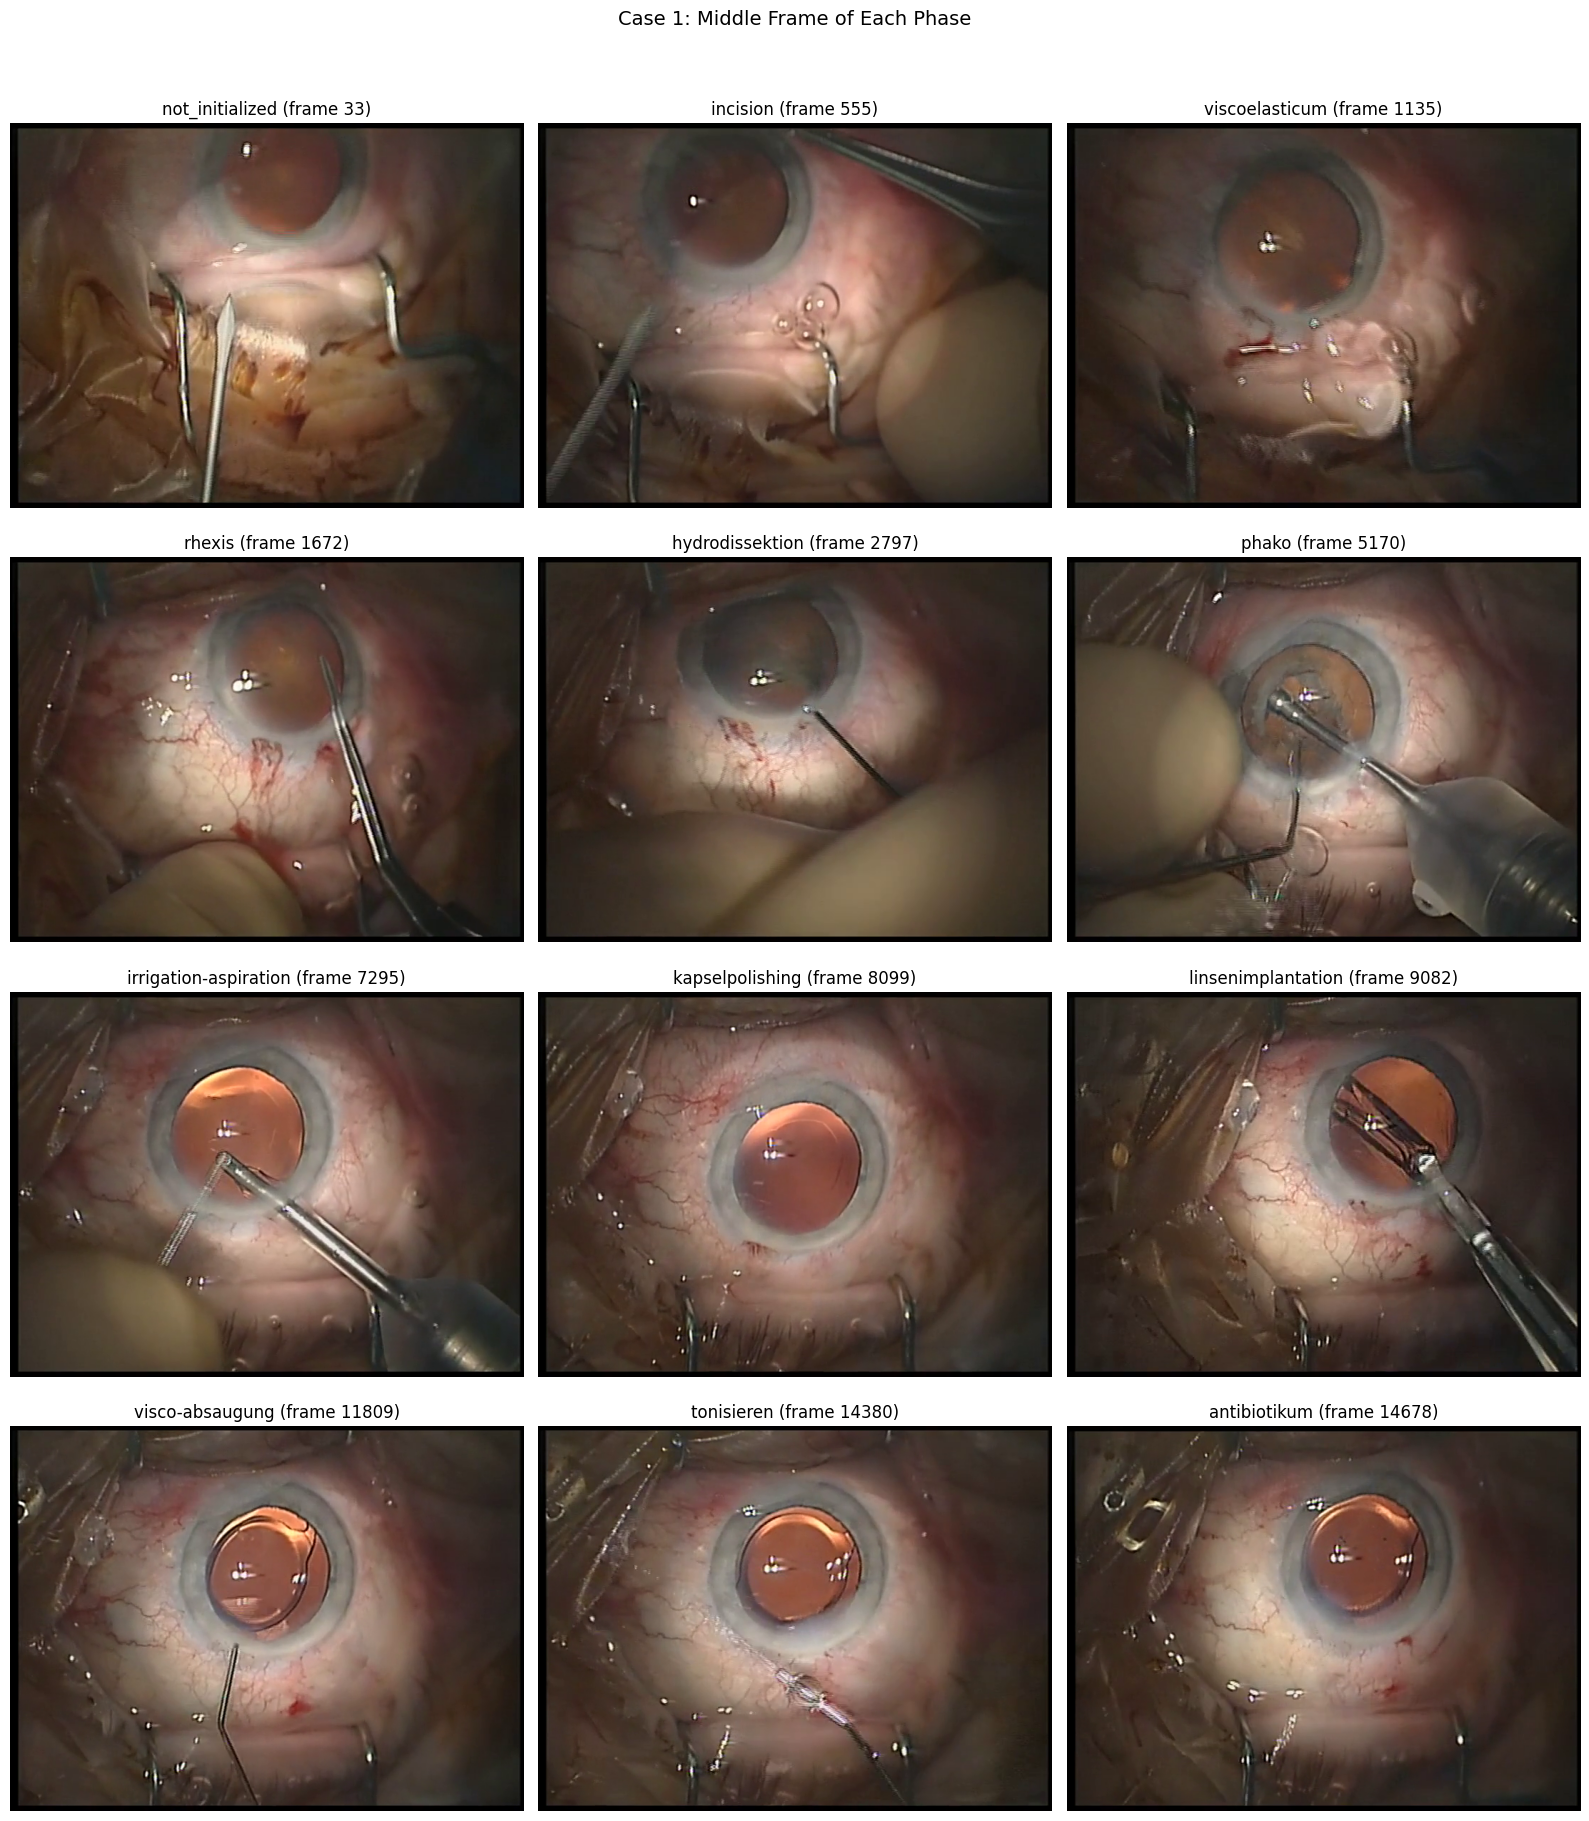

,case_id,phase,start_frame,end_frame,middle_frame,height,width,channels,dtype,mean_b,mean_g,mean_r,mean_gray,std_gray
0,1,not_initialized,0,67,33,540,720,3,uint8,56.756307,71.489480,92.572623,76.083408,46.086110
1,1,incision,68,1042,555,540,720,3,uint8,59.014717,69.268148,87.033652,73.376206,41.534206
2,1,viscoelasticum,1043,1227,1135,540,720,3,uint8,47.133673,55.334745,71.055000,59.041448,35.705259
3,1,rhexis,1228,2117,1672,540,720,3,uint8,54.168655,64.276813,83.110658,68.714115,43.705629
4,1,hydrodissektion,2118,3477,2797,540,720,3,uint8,54.006605,65.044645,79.992842,68.222978,38.790436
5,1,phako,3478,6863,5170,540,720,3,uint8,65.855764,76.088338,90.374720,79.152904,40.201240
6,1,irrigation-aspiration,6864,7726,7295,540,720,3,uint8,63.868421,74.373056,93.466067,78.841983,42.312684
7,1,kapselpolishing,7727,8472,8099,540,720,3,uint8,62.495455,71.696227,93.032917,76.987420,39.817903
8,1,linsenimplantation,8683,9481,9082,540,720,3,uint8,54.452451,63.360412,79.364751,67.095833,43.974431
9,1,visco-absaugung,9482,14137,11809,540,720,3,uint8,64.334787,73.209190,92.289334,77.845185,42.567852


In [ ]:
def show_middle_frame_of_each_phase(case_info: dict[str, object], case_id: int) -> pd.DataFrame:
    '''
    `plot_frame_labels` plots a bar for each case, and a colour represents a label

    `Args:`
        case_info (dict[str, object]): A dictionary containing the video path and frame annotations for one case.
        * Format: { 'video_path': str, 'annotations': { frame_number: label } }

        case_id (int): The case identifier.
        * Format: integer case id

    `Returns:`
        pd.DataFrame: A dataframe with the selected middle frame and image metrics for each phase.
        * Columns: case_id, phase, start_frame, end_frame, middle_frame, height, width, channels, dtype, mean_b, mean_g, mean_r, mean_gray, std_gray
    '''
    if 'video_path' not in case_info or 'annotations' not in case_info:
        raise ValueError('case_info must contain \'video_path\' and \'annotations\'.')

    video_path = case_info['video_path']
    annotations = case_info['annotations']

    if not annotations:
        raise ValueError('This case has no annotations.')

    sorted_items = sorted((int(frame), str(label).lower()) for frame, label in annotations.items())
    frames = [frame for frame, _ in sorted_items]
    labels = [label for _, label in sorted_items]

    segments = []
    start_frame = frames[0]
    current_label = labels[0]
    prev_frame = frames[0]

    for i in range(1, len(frames)):
        frame = frames[i]
        label = labels[i]

        if label != current_label or frame != prev_frame + 1:
            segments.append({
                'label': current_label,
                'start_frame': start_frame,
                'end_frame': prev_frame
            })
            start_frame = frame
            current_label = label

        prev_frame = frame

    segments.append({
        'label': current_label,
        'start_frame': start_frame,
        'end_frame': prev_frame
    })

    selected_segments = []
    seen_labels = set()

    for segment in segments:
        label = segment['label']
        if label in seen_labels:
            continue

        middle_frame = (segment['start_frame'] + segment['end_frame']) // 2
        selected_segments.append({
            'label': label,
            'start_frame': segment['start_frame'],
            'end_frame': segment['end_frame'],
            'middle_frame': middle_frame
        })
        seen_labels.add(label)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f'Could not open video: {video_path}')

    n_phases = len(selected_segments)
    n_cols = 3
    n_rows = int(np.ceil(n_phases / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize= (16, 4.5 * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = np.array([axes])
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)

    metrics_rows = []

    for idx, segment in enumerate(selected_segments):
        row_idx = idx // n_cols
        col_idx = idx % n_cols
        ax = axes[row_idx, col_idx]

        middle_frame = segment['middle_frame']
        cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame)
        ok, frame_bgr = cap.read()

        if not ok or frame_bgr is None:
            ax.axis('off')
            ax.set_title(f'{segment["label"]}\nframe {middle_frame}\nread failed')
            continue

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        frame_gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

        height, width = frame_bgr.shape[:2]
        channels = frame_bgr.shape[2] if frame_bgr.ndim == 3 else 1

        mean_b = float(frame_bgr[:, :, 0].mean())
        mean_g = float(frame_bgr[:, :, 1].mean())
        mean_r = float(frame_bgr[:, :, 2].mean())
        mean_gray = float(frame_gray.mean())
        std_gray = float(frame_gray.std())

        metrics_rows.append({
            'case_id': case_id,
            'phase': segment['label'],
            'start_frame': segment['start_frame'],
            'end_frame': segment['end_frame'],
            'middle_frame': middle_frame,
            'height': height,
            'width': width,
            'channels': channels,
            'dtype': str(frame_bgr.dtype),
            'mean_b': mean_b,
            'mean_g': mean_g,
            'mean_r': mean_r,
            'mean_gray': mean_gray,
            'std_gray': std_gray
        })

        ax.imshow(frame_rgb)
        ax.set_title(f'{segment["label"]} (frame {middle_frame})')
        ax.axis('off')

    total_axes = n_rows * n_cols
    for idx in range(n_phases, total_axes):
        row_idx = idx // n_cols
        col_idx = idx % n_cols
        axes[row_idx, col_idx].axis('off')

    cap.release()
    plt.suptitle(f'Case {case_id}: Middle Frame of Each Phase', y= 1.02, fontsize= 14)
    plt.tight_layout()
    plt.show()

    metrics_df = pd.DataFrame(metrics_rows)

    if not metrics_df.empty:
        display(metrics_df)

    return metrics_df


first_case_id = sorted(cases['train'].keys())[0]
first_case_info = cases['train'][first_case_id]
first_case_metrics_df = show_middle_frame_of_each_phase(case_info= first_case_info, case_id= first_case_id)

# First Model Test

In [ ]:
# ============================================================
# Frame-by-frame classification from `cases`
# - Uses every 3rd frame
# - Reads labels from case annotations
# - Trains Gradient Boosting on train split
# - Evaluates on val split
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd

from bisect import bisect_right
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
FRAME_STEP = 3
IMG_SIZE = (64, 64)          # (width, height)
MAX_FRAMES_PER_VIDEO = None  # e.g. 100 if you want a hard cap
VERBOSE_EVERY = 5

# ------------------------------------------------------------
# Helper: get label for a frame from annotation transitions
# Example annotation format:
# {0: 'idle', 120: 'cutting', 250: 'suturing'}
# Frame 130 gets label 'cutting'
# ------------------------------------------------------------
def get_label_for_frame(frame_no: int, annotations: dict[int, int | str]):
    '''
    Returns the active label for a given frame number
    based on the latest annotation boundary <= frame_no.
    '''
    if not annotations:
        return None

    sorted_frames = sorted(annotations.keys())
    pos = bisect_right(sorted_frames, frame_no) - 1

    if pos < 0:
        return None

    active_frame = sorted_frames[pos]
    return annotations[active_frame]

# ------------------------------------------------------------
# Helper: extract sampled frame features + labels from one video
# ------------------------------------------------------------
def extract_video_frames_and_labels(
    video_path: str,
    annotations: dict[int, int | str],
    frame_step: int = 3,
    img_size: tuple[int, int] = (64, 64),
    max_frames: int | None = None
):
    '''
    Reads a video, keeps every `frame_step` frame,
    converts to grayscale resized flattened features,
    and assigns a label using the annotation dictionary.
    '''
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f'[WARN] Could not open video: {video_path}')
        feature_dim = img_size[0] * img_size[1]
        return (
            np.empty((0, feature_dim), dtype = np.float32),
            np.array([], dtype = object)
        )

    X_list = []
    y_list = []

    frame_no = 0
    kept = 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        if frame_no % frame_step == 0:
            label = get_label_for_frame(frame_no, annotations)

            if label is not None:
                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                resized = cv2.resize(gray, img_size)
                flat = resized.astype(np.float32).flatten() / 255.0

                X_list.append(flat)
                y_list.append(label)
                kept += 1

                if max_frames is not None and kept >= max_frames:
                    break

        frame_no += 1

    cap.release()

    feature_dim = img_size[0] * img_size[1]

    if len(X_list) == 0:
        return (
            np.empty((0, feature_dim), dtype = np.float32),
            np.array([], dtype = object)
        )

    return np.vstack(X_list), np.array(y_list, dtype = object)

# ------------------------------------------------------------
# Helper: build dataset for one split
# ------------------------------------------------------------
def build_split_dataset(
    split_cases: dict[int, dict],
    split_name: str,
    frame_step: int,
    img_size: tuple[int, int],
    max_frames: int | None = None,
    verbose_every: int = 5
):
    X_all = []
    y_all = []

    usable_cases = 0
    skipped_cases = 0
    total_frames = 0

    case_items = list(split_cases.items())

    for idx, (case_id, case_info) in enumerate(case_items, start = 1):
        video_path = case_info['video_path']
        annotations = case_info['annotations']

        if not os.path.exists(video_path):
            print(f'[WARN] Missing video file: {video_path}')
            skipped_cases += 1
            continue

        X_case, y_case = extract_video_frames_and_labels(
            video_path = video_path,
            annotations = annotations,
            frame_step = frame_step,
            img_size = img_size,
            max_frames = max_frames
        )

        if len(X_case) == 0:
            print(f'[WARN] No usable sampled frames for case {case_id}')
            skipped_cases += 1
            continue

        X_all.append(X_case)
        y_all.append(y_case)

        usable_cases += 1
        total_frames += len(y_case)

        if idx % verbose_every == 0 or idx == len(case_items):
            print(
                f'[{split_name}] Processed {idx}/{len(case_items)} cases | '
                f'usable: {usable_cases} | skipped: {skipped_cases} | '
                f'frames: {total_frames}'
            )

    if len(X_all) == 0:
        raise ValueError(f'No usable data found for split: {split_name}')

    X = np.vstack(X_all)
    y = np.concatenate(y_all)

    print(f'\n[{split_name}] Summary')
    print(f'Usable cases:  {usable_cases}')
    print(f'Skipped cases: {skipped_cases}')
    print(f'Total frames:  {total_frames}')
    print(f'X shape:       {X.shape}')
    print(f'y shape:       {y.shape}')

    return X, y

# ------------------------------------------------------------
# Build train and val datasets
# ------------------------------------------------------------
print('Building TRAIN dataset...')
X_train, y_train = build_split_dataset(
    split_cases = cases['train'],
    split_name = 'train',
    frame_step = FRAME_STEP,
    img_size = IMG_SIZE,
    max_frames = MAX_FRAMES_PER_VIDEO,
    verbose_every = VERBOSE_EVERY
)

print('\nBuilding VAL dataset...')
X_val, y_val = build_split_dataset(
    split_cases = cases['val'],
    split_name = 'val',
    frame_step = FRAME_STEP,
    img_size = IMG_SIZE,
    max_frames = MAX_FRAMES_PER_VIDEO,
    verbose_every = VERBOSE_EVERY
)

# ------------------------------------------------------------
# Optional: show class distribution
# ------------------------------------------------------------
print('\nTrain label distribution:')
print(pd.Series(y_train).value_counts().sort_index())

print('\nVal label distribution:')
print(pd.Series(y_val).value_counts().sort_index())

# ------------------------------------------------------------
# Train model
# ------------------------------------------------------------
clf = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 42
)

print('\nTraining Gradient Boosting...')
clf.fit(X_train, y_train)

# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------
y_val_pred = clf.predict(X_val)

print('\nValidation Metrics')
print(f'Accuracy:    {accuracy_score(y_val, y_val_pred):.4f}')
print(f'Weighted F1: {f1_score(y_val, y_val_pred, average = "weighted"):.4f}')
print(f'Macro F1:    {f1_score(y_val, y_val_pred, average = "macro"):.4f}')

print('\nClassification Report')
print(classification_report(y_val, y_val_pred, digits = 4))

print('Confusion Matrix')
print(confusion_matrix(y_val, y_val_pred))

Building TRAIN dataset...
[train] Processed 5/17 cases | usable: 5 | skipped: 0 | frames: 16175
[train] Processed 10/17 cases | usable: 10 | skipped: 0 | frames: 36538
[train] Processed 15/17 cases | usable: 15 | skipped: 0 | frames: 54887
[train] Processed 17/17 cases | usable: 17 | skipped: 0 | frames: 59519

[train] Summary
Usable cases:  17
Skipped cases: 0
Total frames:  59519
X shape:       (59519, 4096)
y shape:       (59519,)

Building VAL dataset...
[val] Processed 4/4 cases | usable: 4 | skipped: 0 | frames: 12533

[val] Summary
Usable cases:  4
Skipped cases: 0
Total frames:  12533
X shape:       (12533, 4096)
y shape:       (12533,)

Train label distribution:
Antibiotikum               513
Hydrodissektion           3192
Incision                  2216
Irrigation-Aspiration     8667
Kapselpolishing           2741
Linsenimplantation        3930
Phako                    18224
Rhexis                    4532
Tonisieren                2478
Visco-Absaugung           9166
Viscoelast